# Time Series Naive
**Author:** Alejandro Orellana

**Date:** Feburary 6, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

**Purpose:** Using the naive time series model and added more features to better understand what explains energy use

## Section 1: Loading Data

In [1]:
from utils.data_utils import load_data, load_neighborhood_geojson
from utils.fix_effect_utils import (
    check_var_count_for_var,
    map_community,
    ols_compare_and_pred_plot,
    plotting_r_sqared,
    prepared_dataframe,
)

geojson_data = load_neighborhood_geojson()
analysis_df = prepared_dataframe(load_data())
target_col = "Site EUI (kBtu/sq ft)"
analysis_df["geo_mapped_name"] = analysis_df["Community Area"].apply(map_community)
analysis_df = analysis_df.sort_values(["ID", "Data Year"])

2026-03-01 01:02:38,016 [INFO] Loading GeoJSON from: /project/data/chicago_geo/neighborhood_chi.geojson
2026-03-01 01:02:38,052 [INFO] Loaded 98 features
2026-03-01 01:02:38,562 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-03-01 01:02:38,564 [INFO] Category counts:
COVID Impact Category
Other                   505
Permanent              1813
Stable/Increased       7470
Temporary/Rebounded    1716


# Dropping all the unique buildings with at least 1 missing Site EUI

In [2]:
missing_counts = analysis_df.groupby("ID").agg(
    Missing_Data=("Site EUI (kBtu/sq ft)", lambda x: x.isna().sum())
)

dropping_list = missing_counts[missing_counts["Missing_Data"] > 0].index
model_data = analysis_df.copy()
model_data = model_data.sort_values(["ID", "Data Year"])
model_data = model_data.drop(model_data[model_data["ID"].isin(dropping_list)].index)

In [3]:
metrics = analysis_df.columns
index_col = "Data Year"
check_var_count_for_var(metrics, index_col, model_data)

Data Year: 0 missing rows (0.00%)
Missing data (NA) Data Year by Year:
# of Buildings with at least 1 missing of Data Year: 0 (0.00%%) buildings 

ID: 0 missing rows (0.00%)
Missing data (NA) ID by Year:
# of Buildings with at least 1 missing of ID: 0 (0.00%%) buildings 

Property Name: 0 missing rows (0.00%)
Missing data (NA) Property Name by Year:
# of Buildings with at least 1 missing of Property Name: 0 (0.00%%) buildings 

Address: 0 missing rows (0.00%)
Missing data (NA) Address by Year:
# of Buildings with at least 1 missing of Address: 0 (0.00%%) buildings 

ZIP Code: 0 missing rows (0.00%)
Missing data (NA) ZIP Code by Year:
# of Buildings with at least 1 missing of ZIP Code: 0 (0.00%%) buildings 

Community Area: 0 missing rows (0.00%)
Missing data (NA) Community Area by Year:
# of Buildings with at least 1 missing of Community Area: 0 (0.00%%) buildings 

Primary Property Type: 0 missing rows (0.00%)
Missing data (NA) Primary Property Type by Year:
# of Buildings with at lea

### Filling missing data from the previous year and making other columns

In [4]:
filling_cols = ["Gross Floor Area - Buildings (sq ft)", "Year Built"]
for col in filling_cols:
    model_data[col] = analysis_df.groupby("ID")[col].transform(
        lambda x: x.ffill().bfill()
    )

model_data["Building_Age"] = model_data["Data Year"] - model_data["Year Built"]

In [5]:
remove_year = 2016
cut_off_year = 2023
model_data["Site_EUI_Lag1"] = model_data.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(1)
model_data["Site_EUI_Lag2"] = model_data.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(2)
model_data["Momentum"] = model_data["Site_EUI_Lag1"] - model_data["Site_EUI_Lag2"]

model_data = model_data[model_data["Data Year"] != remove_year]
train_df = model_data[model_data["Data Year"] < cut_off_year]
test_df = model_data[model_data["Data Year"] == cut_off_year]
print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")

Training Samples: 7284 | Testing Samples: 1214


Running OLS on Target: Site EUI (kBtu/sq ft)


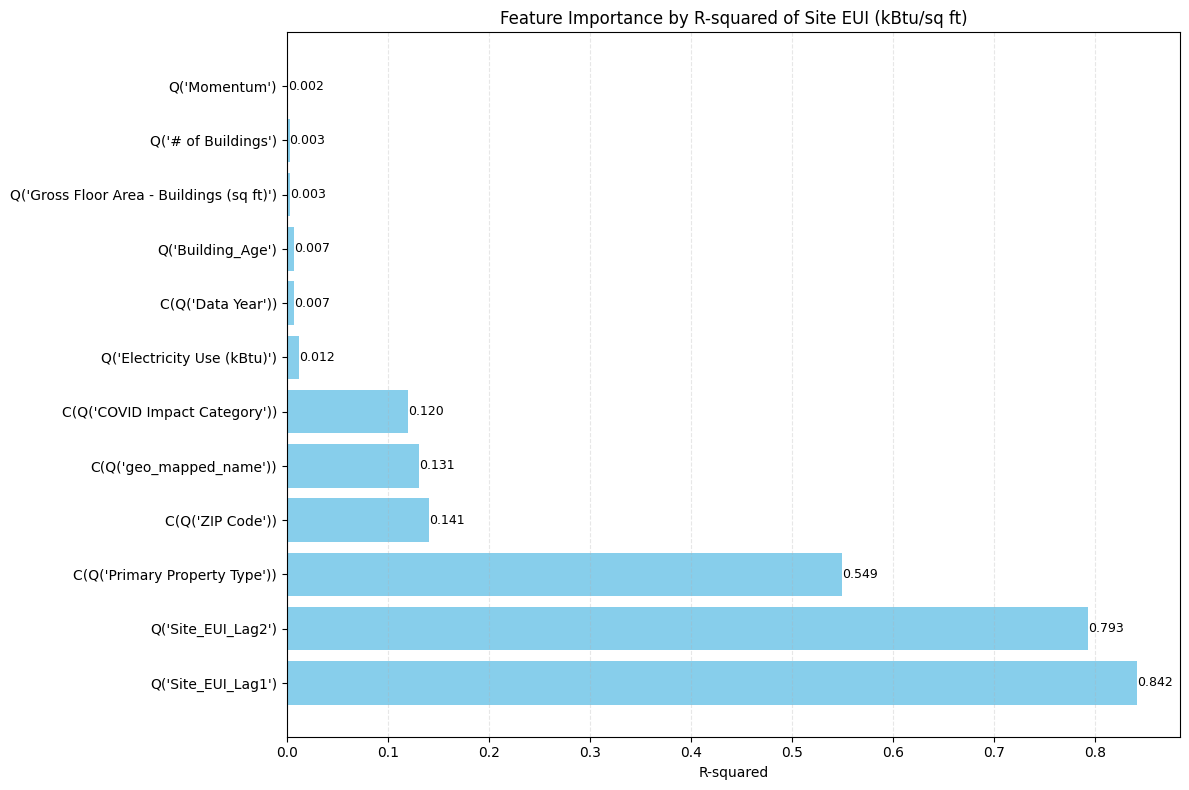

In [6]:
target_col = "Site EUI (kBtu/sq ft)"

exclude_cols = [target_col, "Site_EUI_Lag1"]
q_feature_cols = [
    "Site_EUI_Lag1",
    "Site_EUI_Lag2",
    "Momentum",
    "Gross Floor Area - Buildings (sq ft)",
    "# of Buildings",
    "Electricity Use (kBtu)",
    "Building_Age",
]
c_feature_cols = [
    "ZIP Code",
    "geo_mapped_name",
    "Primary Property Type",
    "COVID Impact Category",
    "Data Year",
]

plotting_r_sqared(target_col, q_feature_cols, c_feature_cols, train_df)

This graph above shows the order of what features best explains the site EUI. With the location and type of property being highest other than using the past to predict.

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.842
Model:                                    OLS   Adj. R-squared:                  0.842
Method:                         Least Squares   F-statistic:                 3.875e+04
Date:                        Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                                21:00:15   Log-Likelihood:                -32078.
No. Observations:                        7284   AIC:                         6.416e+04
Df Residuals:                            7282   BIC:                         6.417e+04
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


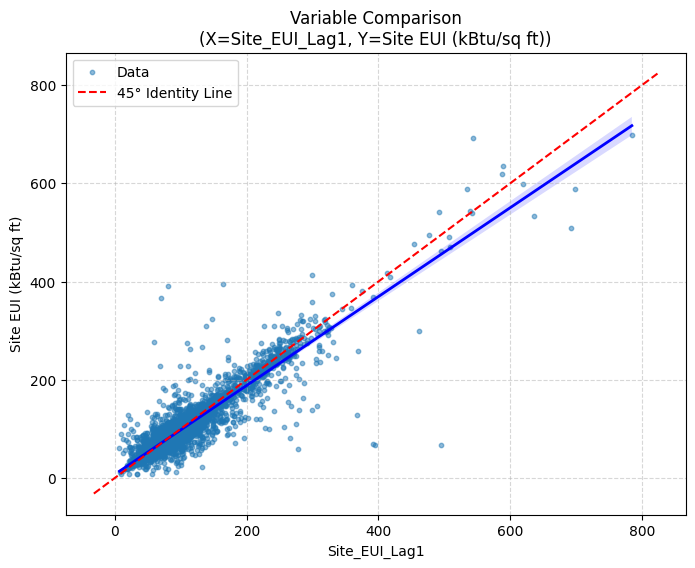

x_col='Predicted_EUI'
y_col='Site EUI (kBtu/sq ft)'


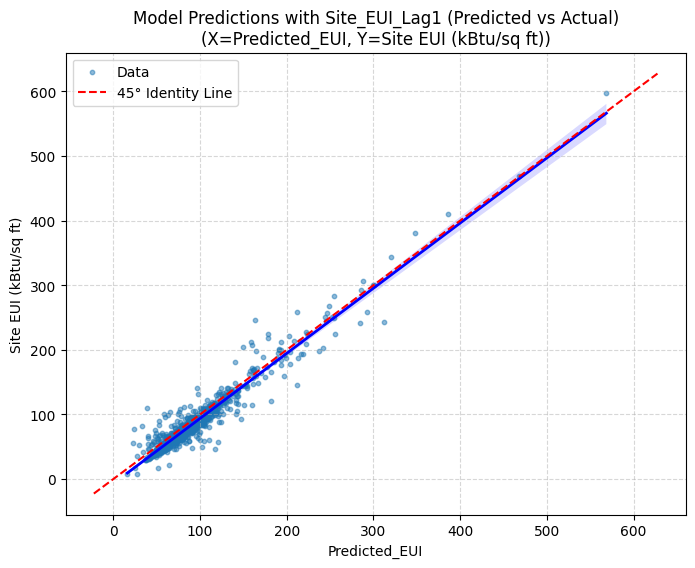

In [7]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ Q('Site_EUI_Lag1')"
y_var = "Site EUI (kBtu/sq ft)"
x_var = "Site_EUI_Lag1"
ols_compare_and_pred_plot(formula, x_var, y_var, model_data, train_df, test_df)

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.549
Model:                                    OLS   Adj. R-squared:                  0.548
Method:                         Least Squares   F-statistic:                     340.0
Date:                        Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                                21:00:16   Log-Likelihood:                -35892.
No. Observations:                        7284   AIC:                         7.184e+04
Df Residuals:                            7257   BIC:                         7.202e+04
Df Model:                                  26                                         
Covariance Type:                    nonrobust                                         
                                                                             coef    std err          t      P>|t|      [0.025    

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


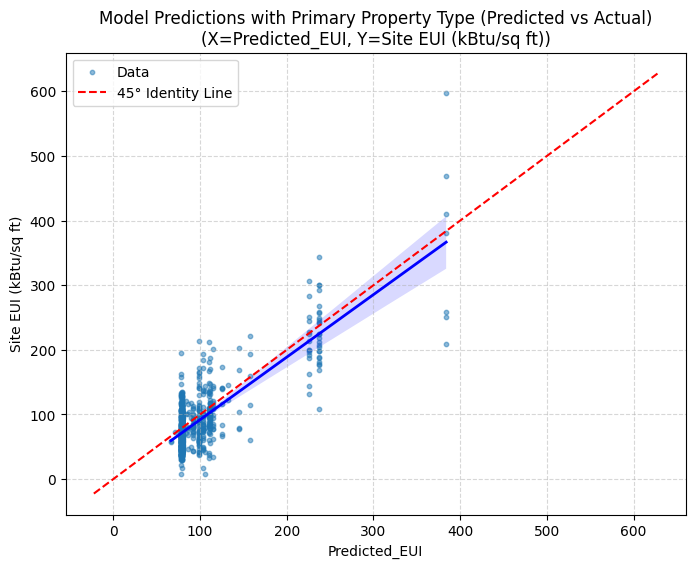

In [8]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ C(Q('Primary Property Type'))"
x_var = "Primary Property Type"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.141
Model:                                    OLS   Adj. R-squared:                  0.132
Method:                         Least Squares   F-statistic:                     17.10
Date:                        Thu, 19 Feb 2026   Prob (F-statistic):          5.85e-185
Time:                                21:00:16   Log-Likelihood:                -38242.
No. Observations:                        7284   AIC:                         7.662e+04
Df Residuals:                            7214   BIC:                         7.711e+04
Df Model:                                  69                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


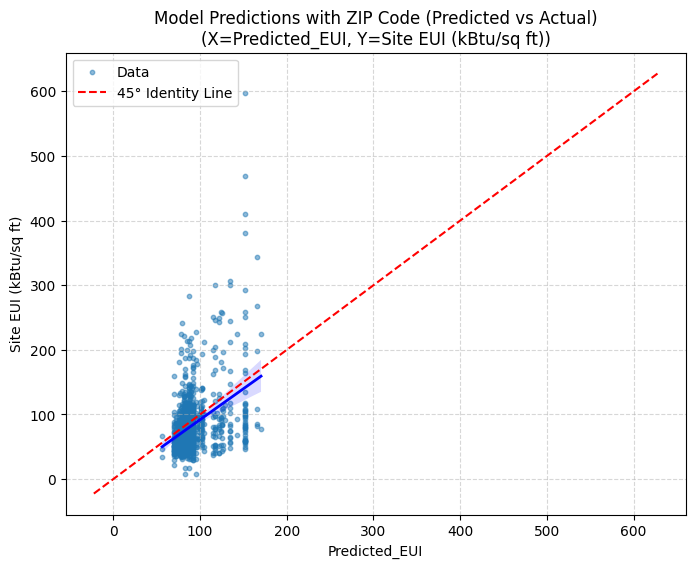

In [9]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ C(Q('ZIP Code'))"
x_var = "ZIP Code"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.851
Model:                                    OLS   Adj. R-squared:                  0.851
Method:                         Least Squares   F-statistic:                     1540.
Date:                        Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                                21:00:17   Log-Likelihood:                -31849.
No. Observations:                        7284   AIC:                         6.375e+04
Df Residuals:                            7256   BIC:                         6.395e+04
Df Model:                                  27                                         
Covariance Type:                    nonrobust                                         
                                                                             coef    std err          t      P>|t|      [0.025    

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


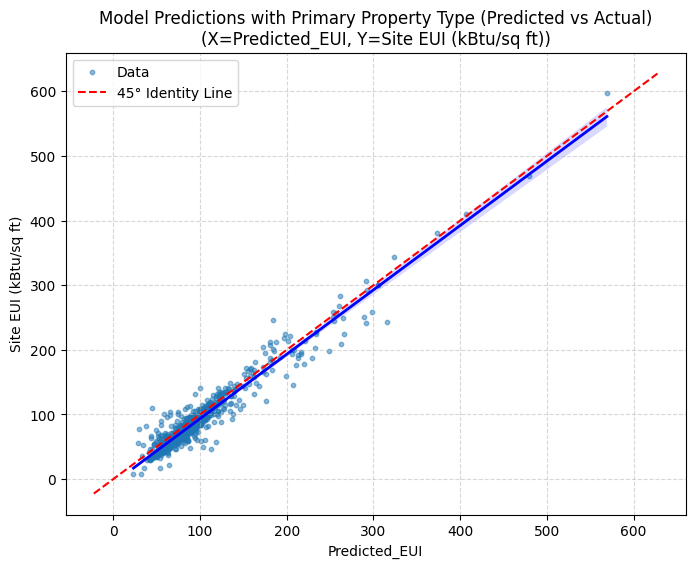

In [10]:
formula = (
    "Q('Site EUI (kBtu/sq ft)') ~ Q('Site_EUI_Lag1') + C(Q('Primary Property Type'))"
)
x_var = "Primary Property Type"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

dependent var: dif of next - avg of next year(site eui)

given a building is it higher or lower based on expectations
- Expectations: avg site eui of next year

- we care about predicting the delta of a buildings site eui change next year of the avg sit eui of next year

- fix effect: year, property type, combo(year, property type)